# Action potential waveforms are state-dependent
### 4. Within-neuron waveform variability can exceed between-neuron differences

Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

For over a century, neuroscience has treated the action potential as a binary, all-or-none event, every spike functionally identical to the next. This paper asks whether that abstraction throws away real information. It turns out the shape of a single spike, not just whether or when it fired, varies with the input driving the neuron, varies more from spike to spike within one neuron than expected, and tracks the surrounding network state.

This notebook walks through one of the paper's five findings. See the [repo README](README.md) for the full picture and the other four notebooks.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os
import matplotlib.pyplot as plt

AP1 = 'AP_empirical_paper_all_analyses'
sys.path.append(f'{AP1}/datasets/spe-1/spe1_helper_modules/')
from spk_feat_cluster_comp_analysis import compile_experiment_results, plot_spike_to_avg_distances
import config
from config import SPE1_PICKLE_ROOT

## Within-neuron waveform variability can exceed between-neuron differences

**Finding:** spike shape isn't always a reliable "fingerprint" of which neuron produced it.

Normally, a neuron's spikes are more similar to each other than to another neuron's spikes. But within-cell shape differences (nRMSE, each spike vs. its own cell's mean waveform) overlap substantially with between-cell differences (each spike vs. every other cell's mean waveform) -- whether compared against all other cells, or only cells of the same type (pyramidal-pyramidal, interneuron-interneuron) or the same recording method.

**Figure:** within-cell vs. between-cell waveform nRMSE, spe-1 population (~167k within-cell, up to ~7M between-cell comparisons) (Fig. 4D).

[spike_to_avg] cache HIT — loading


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/Action potential waveforms are state-dependent paper/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3421: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(GROUP_ORDER, fontsize=_FS, ha='center', multialignment='center')


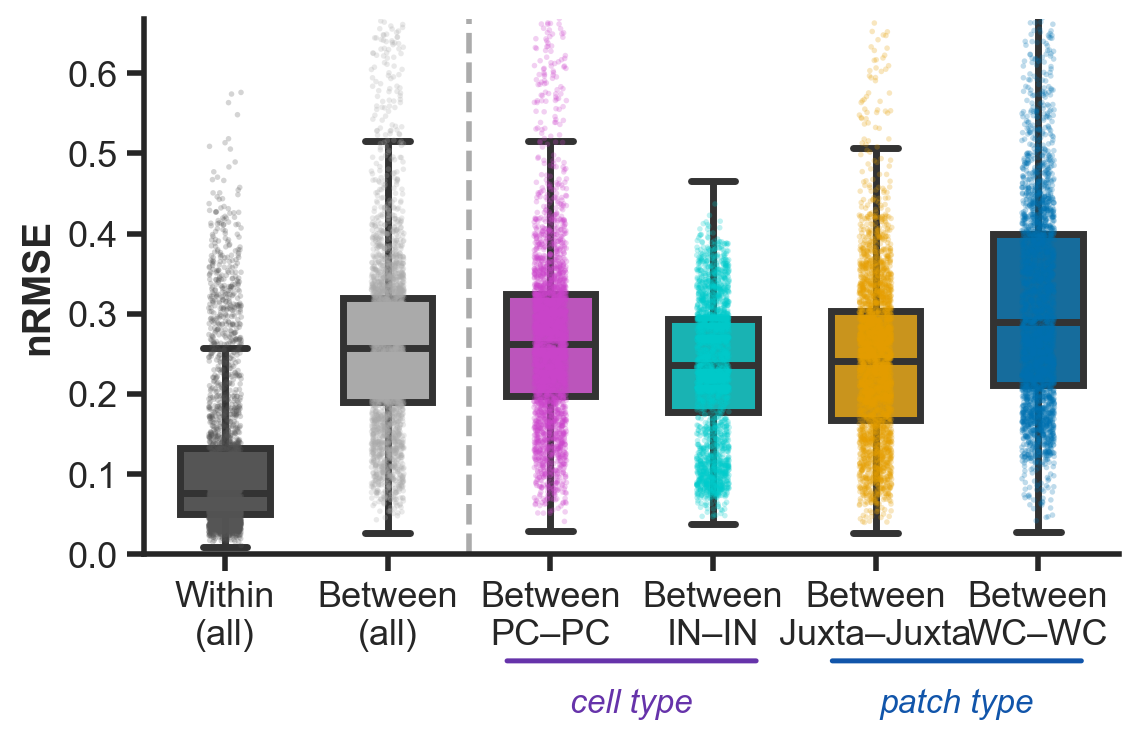


── nRMSE (spike-to-avg) ──
  Within (all)          : median=0.076  IQR=[0.050, 0.133]  n=167006
  Between (all)         : median=0.257  IQR=[0.189, 0.320]  n=200000
  Between PC–PC         : median=0.263  IQR=[0.197, 0.324]  n=200000
  Between IN–IN         : median=0.236  IQR=[0.178, 0.294]  n=200000
  Between Juxta–Juxta   : median=0.241  IQR=[0.167, 0.303]  n=200000
  Between WC–WC         : median=0.290  IQR=[0.211, 0.399]  n=77752


In [2]:
# Same code as pop_within_vs_between_waveform.ipynb, cells 1-4.
cluster_pickle_dir = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles')
spike_fit_dir      = os.path.join(SPE1_PICKLE_ROOT, 'spike_fit_pickles')

df_master = compile_experiment_results(cluster_pickle_dir)

plot_spike_to_avg_distances(
    df_master,
    wf_dir=cluster_pickle_dir,
    spike_fit_dir=spike_fit_dir,
    half_win=75,
    metrics=['nRMSE'],
)